# Brain Tumor Classifier using Support Vector Machine (SVM)

- classifies MRI scans as glioma, meningioma, pituitary, or no tumor  
- use an RBF-kernel SVM for efficiency.
- trains on 256x256 grayscale images from images/Training and images/Testing  
- tracks training and validation accuracy each epoch  
- includes a quick test function to predict any single image and show its confidence

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# load data into two arrays of data and labels
def load_data(root, classes):
    data = []
    labels = []
    for l in classes:
        folder = os.path.join(root, l)
        for d in tqdm(os.listdir(folder), desc=f"Loading {l}"):
            path = os.path.join(folder, d)
            if d.endswith(".npy"):
                data.append(np.load(path).flatten())
                labels.append(l)
    return np.array(data), np.array(labels)

root = os.path.dirname(os.path.abspath("SVM.ipynb"))
training_folder = os.path.join(root, "dataset", "Training")
testing_folder = os.path.join(root, "dataset", "Testing")
classes = ["glioma", "meningioma", "pituitary", "notumor"]
x_train, y_train = load_data(training_folder, classes)
x_test, y_test = load_data(testing_folder, classes)
print(f"Training data shape: {x_train.shape}, Training labels shape: {y_train.shape}")

Loading notumor: 100%|██████████| 810/810 [00:00<00:00, 8059.21it/s]

Training data shape: (5712, 65536), Training labels shape: (5712,)


In [ ]:
PCA_N_COMPONENTS = 100

pca = PCA(n_components=PCA_N_COMPONENTS)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

svc_rbf = SVC(kernel='rbf', C=10, gamma='scale')
svc_rbf.fit(x_train_pca, y_train)
y_train_pred = svc_rbf.predict(x_train_pca)
print("Training accuracy (RBF Kernel):", accuracy_score(y_train, y_train_pred))
y_test_pred = svc_rbf.predict(x_test_pca)
print("Testing accuracy (RBF Kernel):", accuracy_score(y_test, y_test_pred))
print("Classification Report (RBF Kernel):")
print(classification_report(y_test, y_test_pred, target_names=classes, digits=3))


Training accuracy (RBF Kernel): 1.0
Testing accuracy (RBF Kernel): 0.9641495041952708
Classification Report (RBF Kernel):
              precision    recall  f1-score   support

      glioma      0.959     0.937     0.948       300
  meningioma      0.959     0.918     0.938       306
   pituitary      0.976     1.000     0.988       405
     notumor      0.958     0.990     0.974       300

    accuracy                          0.964      1311
   macro avg      0.963     0.961     0.962      1311
weighted avg      0.964     0.964     0.964      1311



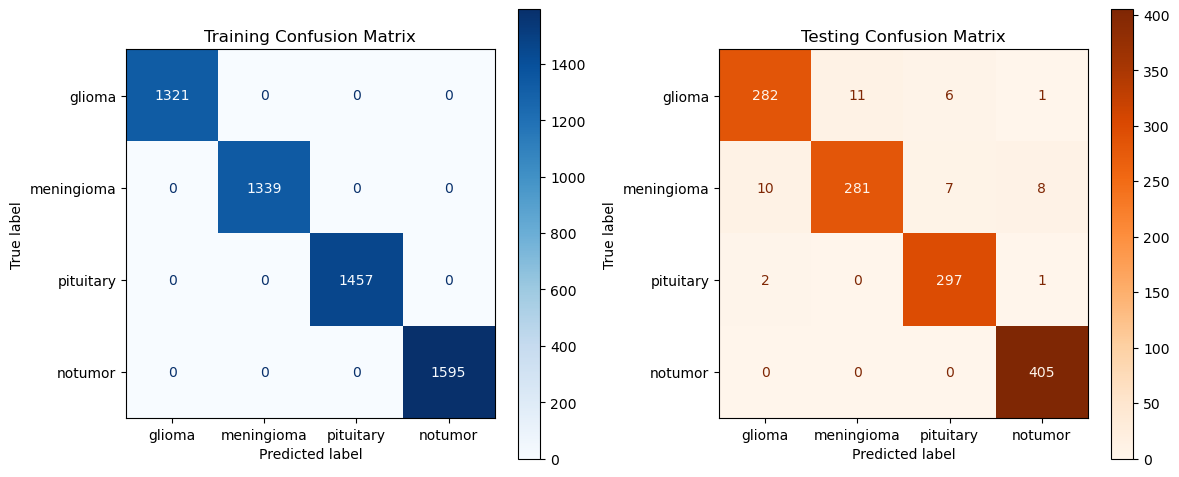

In [26]:
cm_train = confusion_matrix(y_train, y_train_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=classes)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
disp.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title("Training Confusion Matrix")
cm_test = confusion_matrix(y_test, y_test_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=classes)
disp.plot(ax=axes[1], cmap=plt.cm.Oranges)
axes[1].set_title("Testing Confusion Matrix")
plt.tight_layout()
plt.show()

In [31]:
svc_poly_3 = SVC(kernel='poly', degree=3, C=10, gamma='scale')
svc_poly_3.fit(x_train_pca, y_train)
y_train_pred_poly_3 = svc_poly_3.predict(x_train_pca)
print("Training accuracy (Polynomial Kernel Degree 3):", accuracy_score(y_train, y_train_pred_poly_3))
y_test_pred_poly_3 = svc_poly_3.predict(x_test_pca)
print("Testing accuracy (Polynomial Kernel Degree 3):", accuracy_score(y_test, y_test_pred_poly_3))
print("Classification Report (Polynomial Kernel Degree 3):")
print(classification_report(y_test, y_test_pred_poly_3, target_names=classes))
svc_poly_5 = SVC(kernel='poly', degree=5, C=10, gamma='scale')
svc_poly_5.fit(x_train_pca, y_train)
y_train_pred_poly_5 = svc_poly_5.predict(x_train_pca)
print("Training accuracy (Polynomial Kernel Degree 5):", accuracy_score(y_train, y_train_pred_poly_5))
y_test_pred_poly_5 = svc_poly_5.predict(x_test_pca)
print("Testing accuracy (Polynomial Kernel Degree 5):", accuracy_score(y_test, y_test_pred_poly_5))
print("Classification Report (Polynomial Kernel Degree 5):")
print(classification_report(y_test, y_test_pred_poly_5, target_names=classes))

Training accuracy (Polynomial Kernel Degree 3): 1.0
Testing accuracy (Polynomial Kernel Degree 3): 0.965675057208238
Classification Report (Polynomial Kernel Degree 3):
              precision    recall  f1-score   support

      glioma       0.95      0.95      0.95       300
  meningioma       0.98      0.92      0.95       306
   pituitary       0.96      1.00      0.98       405
     notumor       0.97      0.98      0.98       300

    accuracy                           0.97      1311
   macro avg       0.97      0.96      0.96      1311
weighted avg       0.97      0.97      0.97      1311

Training accuracy (Polynomial Kernel Degree 5): 1.0
Testing accuracy (Polynomial Kernel Degree 5): 0.9359267734553776
Classification Report (Polynomial Kernel Degree 5):
              precision    recall  f1-score   support

      glioma       0.95      0.88      0.91       300
  meningioma       0.98      0.88      0.93       306
   pituitary       0.88      1.00      0.94       405
     notu

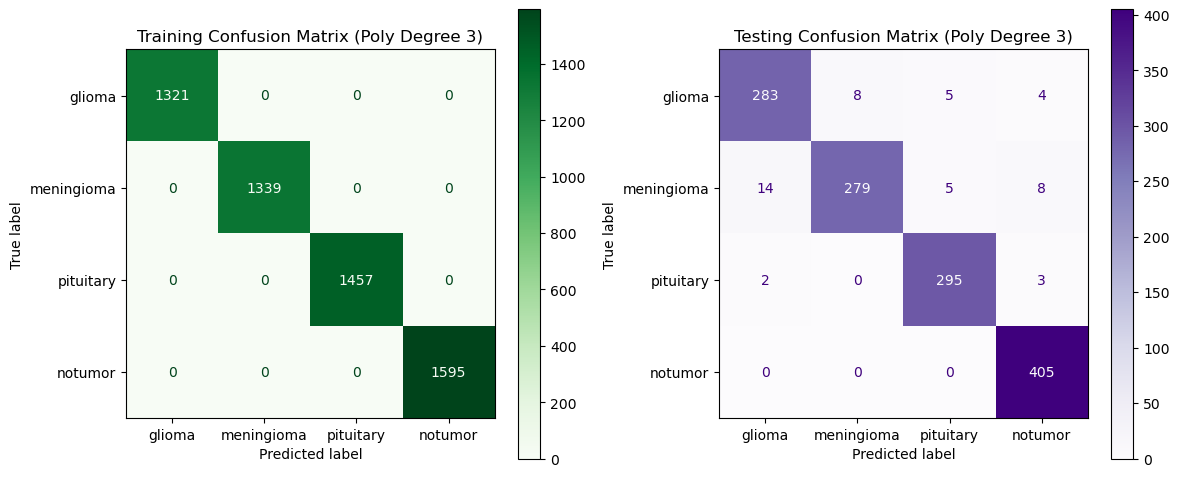

In [28]:
cm_train = confusion_matrix(y_train, y_train_pred_poly_3, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=classes)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
disp.plot(ax=axes[0], cmap=plt.cm.Greens)
axes[0].set_title("Training Confusion Matrix (Poly Degree 3)")
cm_test = confusion_matrix(y_test, y_test_pred_poly_3, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=classes)
disp.plot(ax=axes[1], cmap=plt.cm.Purples)
axes[1].set_title("Testing Confusion Matrix (Poly Degree 3)")
plt.tight_layout()
plt.show()

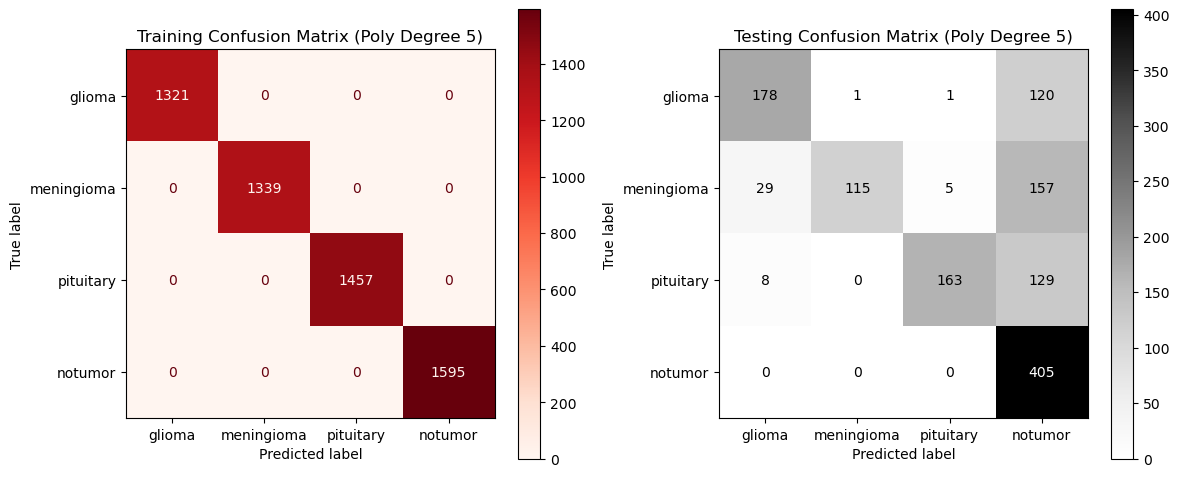

In [29]:
cm_train = confusion_matrix(y_train, y_train_pred_poly_5, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=classes)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
disp.plot(ax=axes[0], cmap=plt.cm.Reds)
axes[0].set_title("Training Confusion Matrix (Poly Degree 5)")
cm_test = confusion_matrix(y_test, y_test_pred_poly_5, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=classes)
disp.plot(ax=axes[1], cmap=plt.cm.Greys)    
axes[1].set_title("Testing Confusion Matrix (Poly Degree 5)")
plt.tight_layout()
plt.show()